# Deconvolving Visium spots with RCTD

Runs the real **RCTD** ([`spacexr`](https://github.com/dmcable/spacexr), Cable et al. 2022) on a
simulated Visium-style section and scores its per-spot cell-type proportions against the composition
`iscc` actually placed in each spot.

**R notebook**, kernel `R (iscc-rctd)`, no simulation. Generated once by
`python validation/make_analysis_data.py --only rctd`:

| file | what it is | who sees it |
|---|---|---|
| `sp_counts.csv`, `sp_coords.csv` | the spatial section: genes × spots, and spot coordinates | the tool |
| `ref_counts.csv`, `ref_labels.csv` | a paired scRNA reference and its cell-type labels | the tool |
| `truth_type_composition.csv` | true per-spot cell-type proportions | **scoring only** |
| `truth_clone_composition.csv` | true per-spot CNA-clone proportions | **scoring only** |

**Why this benchmark is worth having.** Deconvolution methods are normally validated against a
reference that came from the same tissue but a different assay, so the "truth" is itself an estimate.
Here the truth is exact: `iscc` knows which cells it put in each spot. The reference used below is the
**oracle** one (built from the section's own cells) — an upper bound, not a realistic reference.

Note this dataset is **not yet on the realistic ductal field** — it grows `deconv_common`'s grid-26
substrate, because the section geometry (spot radius, pitch, section radius) is tuned to that grid.
See `_rctd` in `make_analysis_data.py`.

In [1]:
source("r_preamble.R")
suppressMessages({ library(spacexr); library(Matrix) })

data_dir <- analysis_dir("rctd")
read_counts <- function(f) as(as.matrix(read.csv(file.path(data_dir, f), row.names = 1,
                                                 check.names = FALSE)), "dgCMatrix")
ref_counts <- read_counts("ref_counts.csv")     # genes x reference cells
sp_counts  <- read_counts("sp_counts.csv")      # genes x spots
labels <- read.csv(file.path(data_dir, "ref_labels.csv"), row.names = 1, check.names = FALSE)
coords <- read.csv(file.path(data_dir, "sp_coords.csv"), row.names = 1, check.names = FALSE)

cat(sprintf("reference: %d genes x %d cells\nsection:   %d genes x %d spots\n",
            nrow(ref_counts), ncol(ref_counts), nrow(sp_counts), ncol(sp_counts)))
print(table(labels[, 1]))

reference: 6000 genes x 450 cells
section:   6000 genes x 2542 spots



    cancer epithelial     immune    stromal 
       163          8         94        185 


## Fit

RCTD's own pipeline: a `Reference` from the annotated scRNA, a `SpatialRNA` puck from the section,
then `run.RCTD` in `full` mode — which allows any mixture of types per spot, the right setting when a
spot genuinely contains several cells.

In [2]:
cell_types <- factor(labels[colnames(ref_counts), 1])
names(cell_types) <- colnames(ref_counts)

# RCTD needs enough cells per type to estimate its profile; drop types below the floor rather than
# letting it fail deep inside the fit.
min_per_type <- 25
keep <- names(which(table(cell_types) >= min_per_type))
cells <- names(cell_types)[cell_types %in% keep]
ref_counts <- ref_counts[, cells]; cell_types <- droplevels(cell_types[cells])
cat(sprintf("keeping %d types with >= %d cells: %s\n",
            length(keep), min_per_type, paste(keep, collapse = ", ")))

reference <- Reference(ref_counts, cell_types, nUMI = colSums(ref_counts), min_UMI = 1)
coords_df <- data.frame(x = coords$x, y = coords$y); rownames(coords_df) <- rownames(coords)
puck <- SpatialRNA(coords_df, sp_counts, nUMI = colSums(sp_counts), require_int = TRUE)

myRCTD <- create.RCTD(puck, reference, max_cores = 1, CELL_MIN_INSTANCE = min_per_type,
                      UMI_min = 1, counts_MIN = 1, test_mode = FALSE)
myRCTD <- run.RCTD(myRCTD, doublet_mode = "full")

W <- as.matrix(myRCTD@results$weights)
W <- sweep(W, 1, pmax(rowSums(W), 1e-9), "/")      # weights -> proportions
cat(sprintf("\nfitted %d spots x %d cell types\n", nrow(W), ncol(W)))
round(head(W, 4), 3)

keeping 3 types with >= 25 cells: cancer, immune, stromal


Begin: process_cell_type_info



process_cell_type_info: number of cells in reference: 442



process_cell_type_info: number of genes in reference: 6000




 cancer  immune stromal 
    163      94     185 


...

Sigma value:  2



Likelihood value: 1217200.16633612



Sigma value:  2




fitted 2542 spots x 3 cell types


,cancer,immune,stromal
S0,0.254,0.045,0.701
S1,0.872,0.042,0.086
S2,0.779,0.133,0.088
S3,0.749,0.073,0.178


## Scoring against the true composition

Now open the truth. Two measures, because they answer different questions: **per-spot correlation**
asks whether the *shape* of each spot's mixture is right, and **mean absolute error** asks how far off
the proportions are in absolute terms. A method can score well on one and poorly on the other.

In [3]:
truth <- read.csv(file.path(data_dir, "truth_type_composition.csv"),
                  row.names = 1, check.names = FALSE)

common_spots <- intersect(rownames(W), rownames(truth))
common_types <- intersect(colnames(W), colnames(truth))
P <- W[common_spots, common_types, drop = FALSE]
T <- as.matrix(truth[common_spots, common_types, drop = FALSE])
cat(sprintf("scoring %d spots over %d shared types: %s\n",
            length(common_spots), length(common_types), paste(common_types, collapse = ", ")))

per_type_r <- sapply(common_types, function(k)
  if (sd(T[, k]) < 1e-9 || sd(P[, k]) < 1e-9) NA_real_ else cor(P[, k], T[, k]))
mae <- mean(abs(P - T))
# A flat "every type in equal proportion" guess is the baseline worth beating on MAE.
flat <- matrix(1 / ncol(T), nrow(T), ncol(T))
cat(sprintf("\nRCTD vs iscc ground truth (ORACLE reference — an upper bound)\n"))
cat(sprintf("  mean |error| %.3f   (flat-guess baseline %.3f)\n", mae, mean(abs(flat - T))))
cat("  per-type correlation:\n")
print(round(per_type_r, 3))
cat(sprintf("\n  mean per-type r: %.3f\n", mean(per_type_r, na.rm = TRUE)))

scoring 2542 spots over 3 shared types: cancer, immune, stromal



RCTD vs iscc ground truth (ORACLE reference — an upper bound)


  mean |error| 0.058   (flat-guess baseline 0.277)


  per-type correlation:


 cancer  immune stromal 
  0.979   0.967   0.977 



  mean per-type r: 0.974


## The map, drawn by RCTD's own plotting

`plot_puck_continuous` is `spacexr`'s spatial plotter — the function its vignette uses to show a
value across a puck. Here it draws RCTD's estimated cancer weight over the section, beside the true
cancer fraction `iscc` placed there. The point is not the correlation coefficient; it is that the
map is legible as tissue.

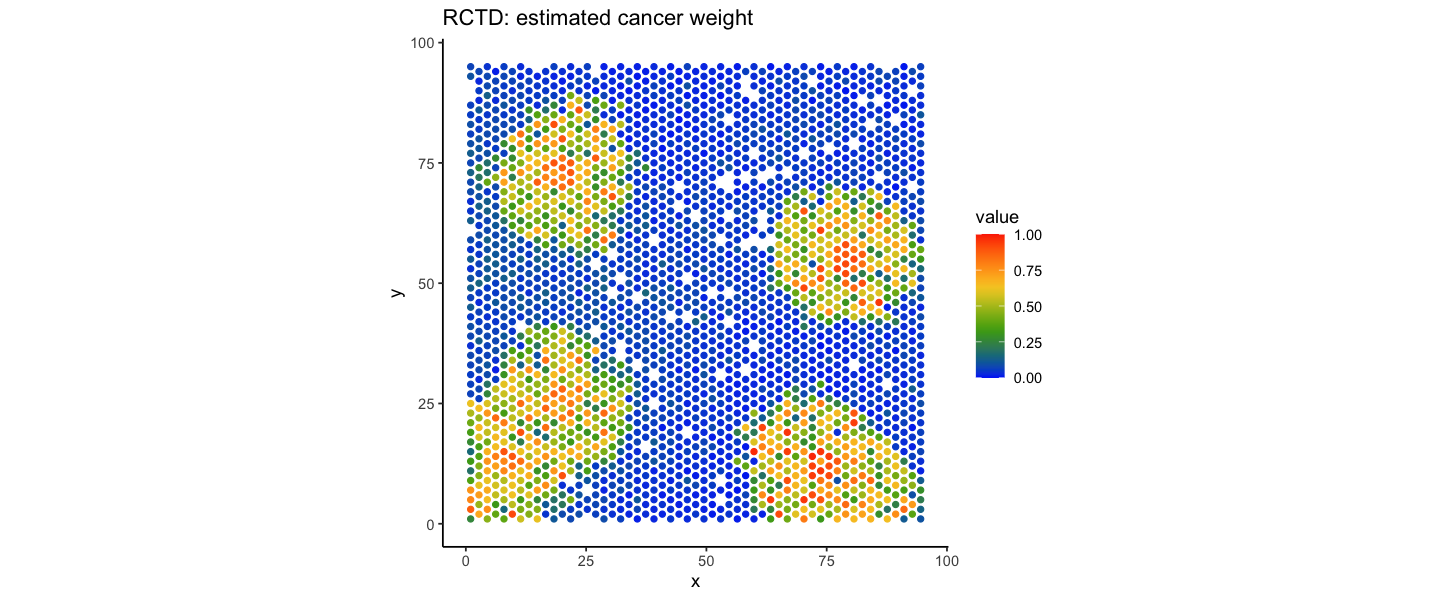

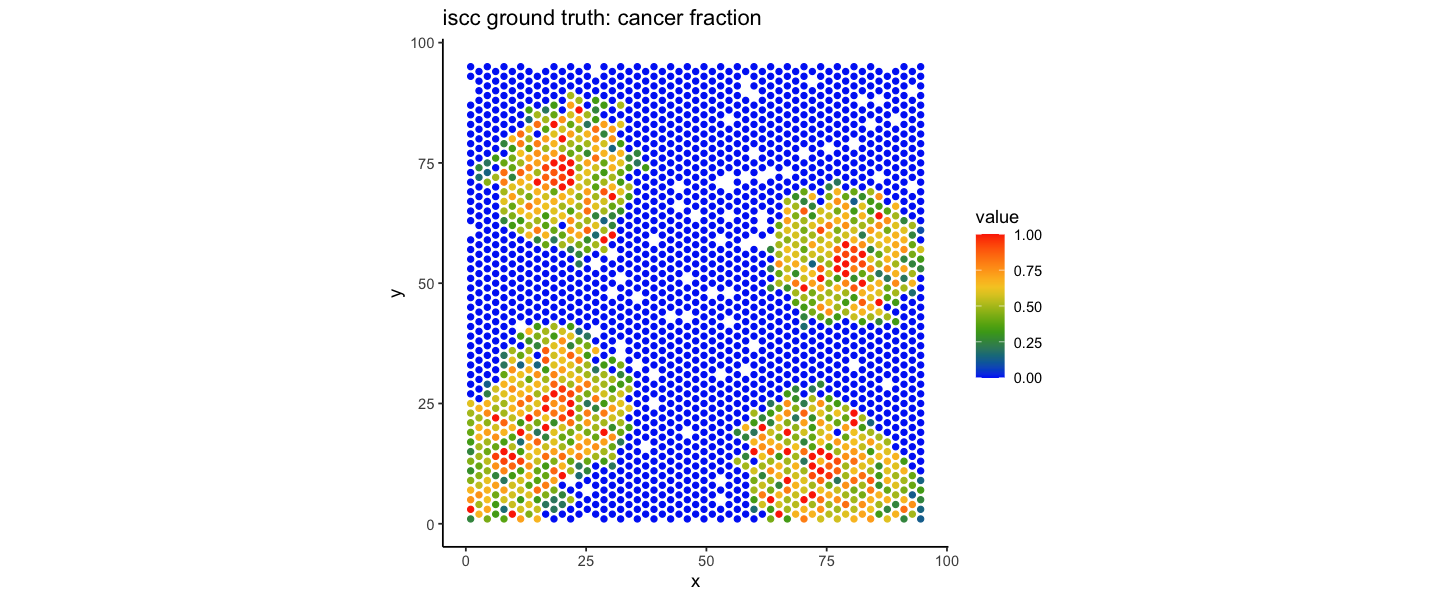

In [4]:
suppressMessages(library(ggplot2))
options(repr.plot.width = 12, repr.plot.height = 5)

spots <- rownames(W)
p_est <- plot_puck_continuous(puck, spots, W[, "cancer"], ylimit = c(0, 1),
                              title = "RCTD: estimated cancer weight", size = 1.4)
truth_v <- setNames(as.numeric(truth[spots, "cancer"]), spots)
p_true <- plot_puck_continuous(puck, spots, truth_v, ylimit = c(0, 1),
                               title = "iscc ground truth: cancer fraction", size = 1.4)
suppressWarnings(print(p_est)); suppressWarnings(print(p_true))

### Every type, the same way

`spacexr` ships `plot_weights()`, which draws exactly these panels for every fitted type — but writes
them to a PDF on disk. Inline, that is the same native plotter called in a loop.

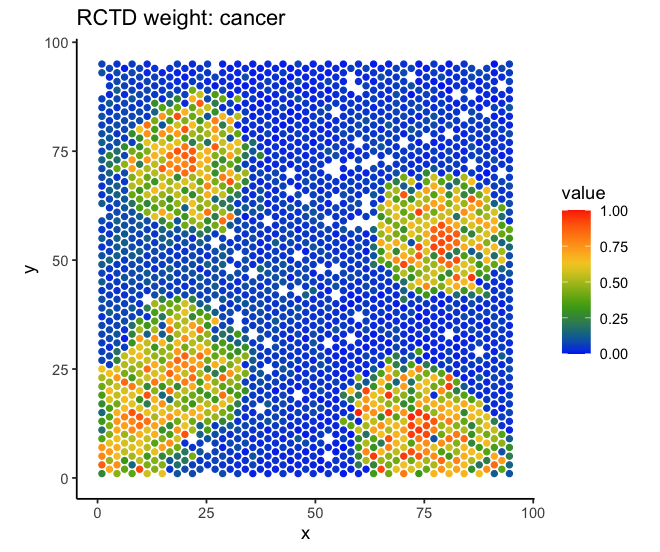

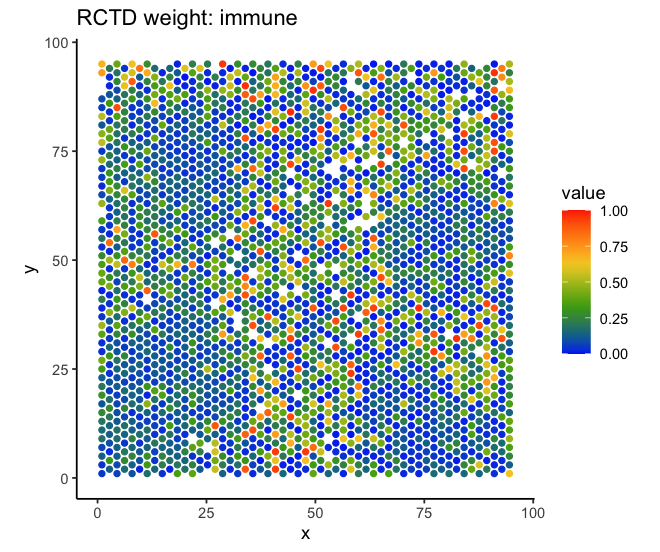

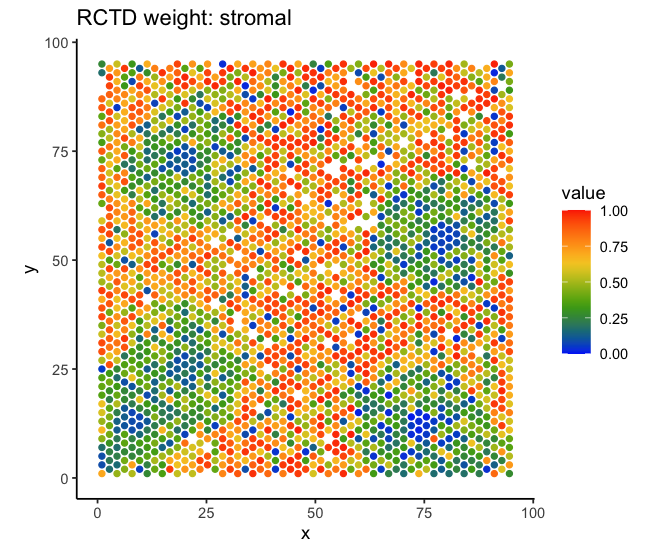

In [5]:
options(repr.plot.width = 5.5, repr.plot.height = 4.6)
for (k in colnames(W)) {
  suppressWarnings(print(
    plot_puck_continuous(puck, spots, W[, k], ylimit = c(0, 1),
                         title = sprintf("RCTD weight: %s", k), size = 1.4)))
}

The same comparison per spot rather than in space — every spot's estimated against its true
proportion, for each cell type.

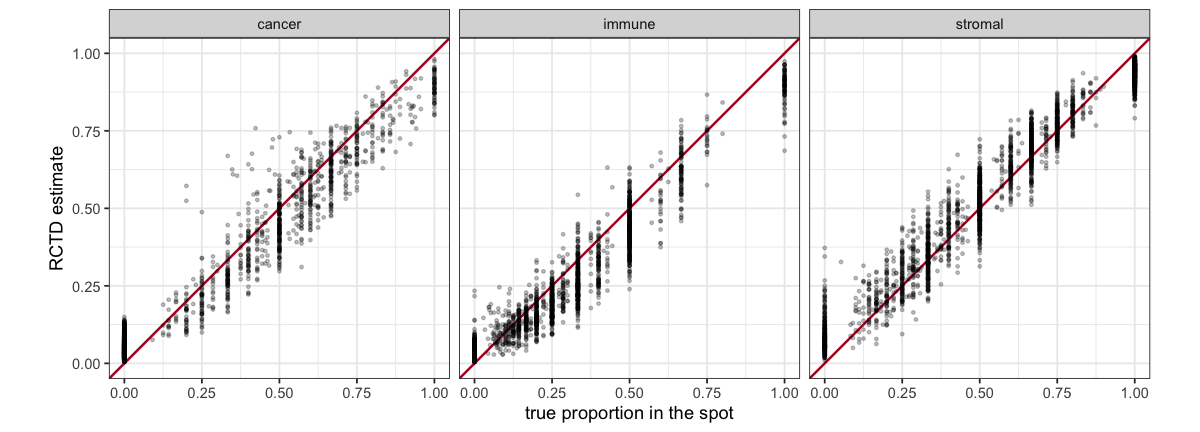

In [6]:
long <- do.call(rbind, lapply(common_types, function(k)
  data.frame(type = k, truth = T[, k], est = P[, k])))
options(repr.plot.width = 10, repr.plot.height = 3.6)
ggplot(long, aes(truth, est)) +
  geom_abline(slope = 1, intercept = 0, colour = "#b2182b", linewidth = 0.7) +
  geom_point(alpha = 0.25, size = 0.7) +
  facet_wrap(~ type, nrow = 1) +
  coord_equal(xlim = c(0, 1), ylim = c(0, 1)) +
  labs(x = "true proportion in the spot", y = "RCTD estimate") +
  theme_bw(base_size = 11)